# Redis Trace Replay Breakpoint Analysis

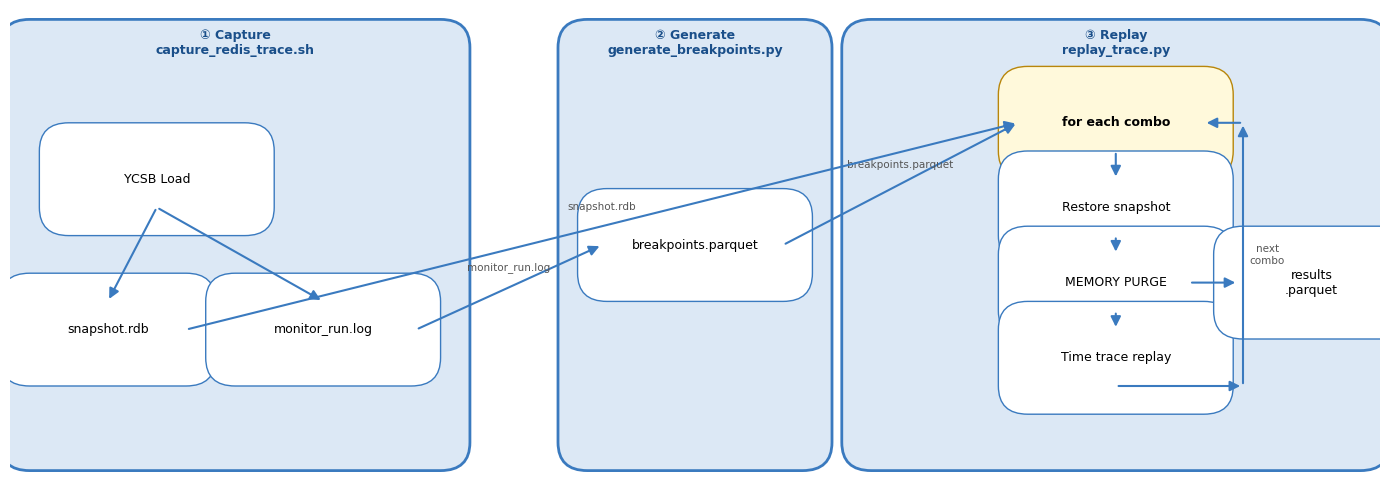

In [22]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

fig, ax = plt.subplots(figsize=(14, 5))
ax.set_xlim(0, 14)
ax.set_ylim(0, 5)
ax.axis("off")

PHASE_STYLE   = dict(boxstyle="round,pad=0.3", facecolor="#dce8f5", edgecolor="#3a7abf", linewidth=2)
NODE_STYLE    = dict(boxstyle="round,pad=0.3", facecolor="white",   edgecolor="#3a7abf", linewidth=1)
DIAMOND_STYLE = dict(boxstyle="round,pad=0.3", facecolor="#fff9db", edgecolor="#b8860b", linewidth=1)
ARROW_KW      = dict(arrowstyle="-|>", color="#3a7abf", lw=1.5,
                     connectionstyle="arc3,rad=0.0",
                     mutation_scale=15)

def box(ax, x, y, w, h, label, style, fontsize=9, bold=False):
    patch = FancyBboxPatch((x - w/2, y - h/2), w, h, **style, transform=ax.transData)
    ax.add_patch(patch)
    weight = "bold" if bold else "normal"
    ax.text(x, y, label, ha="center", va="center", fontsize=fontsize, weight=weight, wrap=True)
    return (x, y, w, h)

def arrow(ax, src, dst, label="", rad=0.0):
    x0, y0 = src[0], src[1]
    x1, y1 = dst[0], dst[1]
    ax.annotate("", xy=(x1, y1), xytext=(x0, y0),
                 arrowprops=dict(arrowstyle="-|>", color="#3a7abf", lw=1.5,
                                 connectionstyle=f"arc3,rad={rad}", mutation_scale=15))
    if label:
        mx, my = (x0 + x1) / 2, (y0 + y1) / 2 + 0.15
        ax.text(mx, my, label, ha="center", va="bottom", fontsize=7.5, color="#555")

# --- Phase outlines ---
box(ax, 2.3,  2.5, 4.2, 4.2, "", PHASE_STYLE)
box(ax, 7.0,  2.5, 2.2, 4.2, "", PHASE_STYLE)
box(ax, 11.3, 2.5, 5.0, 4.2, "", PHASE_STYLE)

# --- Phase titles ---
ax.text(2.3,  4.65, "① Capture\ncapture_redis_trace.sh",  ha="center", va="center", fontsize=9,  weight="bold", color="#1a4f8a")
ax.text(7.0,  4.65, "② Generate\ngenerate_breakpoints.py", ha="center", va="center", fontsize=9,  weight="bold", color="#1a4f8a")
ax.text(11.3, 4.65, "③ Replay\nreplay_trace.py",           ha="center", va="center", fontsize=9,  weight="bold", color="#1a4f8a")

# --- Capture nodes ---
ycsb    = box(ax, 1.5, 3.2, 1.8, 0.6, "YCSB Load",        NODE_STYLE)
rdb     = box(ax, 1.0, 1.6, 1.6, 0.6, "snapshot.rdb",      NODE_STYLE)
mon     = box(ax, 3.2, 1.6, 1.8, 0.6, "monitor_run.log",   NODE_STYLE)
arrow(ax, (1.5, 2.9),  (1.0, 1.9))
arrow(ax, (1.5, 2.9),  (3.2, 1.9))

# --- Generate nodes ---
bp = box(ax, 7.0, 2.5, 1.8, 0.6, "breakpoints.parquet", NODE_STYLE)

# --- Replay nodes ---
combo   = box(ax, 11.3, 3.8, 1.8, 0.6, "for each combo",    DIAMOND_STYLE, bold=True)
restore = box(ax, 11.3, 2.9, 1.8, 0.6, "Restore snapshot",  NODE_STYLE)
purge   = box(ax, 11.3, 2.1, 1.8, 0.6, "MEMORY PURGE",      NODE_STYLE)
timed   = box(ax, 11.3, 1.3, 1.8, 0.6, "Time trace replay", NODE_STYLE)
out     = box(ax, 13.3, 2.1, 1.4, 0.6, "results\n.parquet", NODE_STYLE)
arrow(ax, (11.3, 3.5),  (11.3, 3.2))
arrow(ax, (11.3, 2.6),  (11.3, 2.4))
arrow(ax, (11.3, 1.8),  (11.3, 1.6))
arrow(ax, (11.3, 1.0),  (12.6, 1.0), rad=-0.0)   # next combo arc
ax.annotate("", xy=(12.6, 3.8), xytext=(12.6, 1.0),
             arrowprops=dict(arrowstyle="-|>", color="#3a7abf", lw=1.5, mutation_scale=15))
ax.annotate("", xy=(11.3 + 0.9, 3.8), xytext=(12.6, 3.8),
             arrowprops=dict(arrowstyle="-|>", color="#3a7abf", lw=1.5, mutation_scale=15))
ax.text(12.85, 2.3, "next\ncombo", ha="center", fontsize=7.5, color="#555")
arrow(ax, (12.05, 2.1), (12.55, 2.1))

# --- Phase arrows ---
arrow(ax, (4.15, 1.6), (6.05, 2.5), label="monitor_run.log")
arrow(ax, (7.9,  2.5), (10.3, 3.8), label="breakpoints.parquet")
arrow(ax, (1.8,  1.6), (10.3, 3.8), label="snapshot.rdb")

plt.tight_layout()
plt.show()

In [10]:
import polars as pl
import polars.selectors as cs

In [11]:
RESULTS_PATH = "../../../data/results.parquet"
results = pl.read_parquet(RESULTS_PATH)
results

user1001286784010666373,user1004853045005653158,user1005631320735635489,user1009539227024920839,user1010099187537061287,user1015345330068469416,user1016465251092750312,user1020591472599877545,user1021151433112017993,user1021711393624158441,user1026397575643426122,user1101088394010631707,user1104436339787776609,user1105214615517758940,user1105556260812057505,user1105774576029899388,user1106334536542039836,user1110460758049167069,user1111020718561307517,user1111580679073447965,user1112140639585588413,user1116048545874873763,user1116266861092715646,user1116608506387014211,user1116826821604856094,user1121294688406281892,user1121513003624123775,user1121854648918422340,user1125980870425549573,user1130667052444817254,user1136473155488365831,user1141719298019773960,user1146965440551182089,user1200671688792755158,user1205917831324163287,user1206477791836303735,user1211163973855571416,…,user9119376631661606007,user9119936592173746455,user9125182734705154584,user9125742695217295032,user9130428877236562713,user9130988837748703161,user9136794940792251738,user9195187371053092488,user9200993474096641065,user9206239616628049194,user9209245917110895531,user9210365838135176427,user9210925798647316875,user9213713783912321329,user9216171941178725004,user9216731901690865452,user9219519886955869906,user9220858123197992685,user9221418083710133133,user9221978044222273581,user973594505035046267,user974154465547186715,user974714426059327163,user978622332348612513,user978840647566454396,user979960568590735292,user984428435392161090,user984646750610002973,user985766671634283869,user986326632146424317,user989674577923569219,user991572774677832446,user995139035672819231,user995480680967117796,user996258956697100127,user997378877721381023,runtime_s
i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,…,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,f64
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,14.633111
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,14.946104
0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,14.801694
0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,14.60797
0,0,0,9,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,14.706793
0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,110.776035
0,0,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,68.951795
0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,85.026096
0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,118.807597


In [19]:
breakpoint_cols = cs.all() - cs.by_name("runtime_s")
results.select(
    pl.col("runtime_s"),
    pl.sum_horizontal(breakpoint_cols != 0).alias("num_breakpoints"),
    pl.max_horizontal(breakpoint_cols).alias("max_breakpoint"),
)

runtime_s,num_breakpoints,max_breakpoint
f64,u32,i64
14.633111,0,0
14.946104,1,1
14.801694,1,1
14.60797,1,1
14.706793,1,9
110.776035,1,1
68.951795,1,2
85.026096,1,1
118.807597,1,1
